# X-Learner / Causal Forest

In [33]:
import sys
sys.path.insert(0, "../src")

import pandas as pd

from feature_engineering import split_train_holdout, validate_segment, TREATMENT_COL
from balance_check import CONTROL_LABEL, TREATMENT_LABELS

In [34]:
df = pd.read_csv("../data/hillstrom_email_data.csv")
train_df, holdout_df = split_train_holdout(df)

In [ ]:
counts = train_df[TREATMENT_COL].value_counts()
n_control = counts[CONTROL_LABEL]
n_mens = counts[TREATMENT_LABELS[0]]
n_womens = counts[TREATMENT_LABELS[1]]
n_combined_treatment = n_mens + n_womens
ratio = n_control / n_combined_treatment

FLAG_THRESHOLD = 0.3

print("Training-set group sizes:")
print(counts)
print()
print(f"n_control (No E-Mail):            {n_control}")
print(f"n_combined_treatment (Mens+Womens): {n_combined_treatment}")
print(f"ratio control / combined_treatment: {ratio:.4f}")
print(f"expected ratio under perfect 3-way balance: 0.5000")
print(f"flag threshold (ratio below this = control too small):  {FLAG_THRESHOLD:.4f}")
print()
flagged = ratio < FLAG_THRESHOLD
if flagged:
    print("FLAGGED: True, control group is small relative to the combined treatment arms;")
    print("the baseline estimate may be unstable, biasing CATE for both treatment arms.")
else:
    print("FLAGGED: False, control group is NOT undersized relative to the combined treatment arms.")

Training-set group sizes:
segment
Womens E-Mail    17110
Mens E-Mail      17045
No E-Mail        17045
Name: count, dtype: int64

n_control (No E-Mail):            17045
n_combined_treatment (Mens+Womens): 34155
ratio control / combined_treatment: 0.4990
expected ratio under perfect 3-way balance: 0.5000
flag threshold (ratio below this = control too small):  0.3000

FLAGGED: False -- control group is NOT undersized relative to the combined treatment arms.


In [ ]:
validate_segment(train_df)
print("validate_segment(train_df) passed, no error raised.")
print("Confirmed: 'segment' carries exactly 3 distinct values in the training data,")
print("matching {'No E-Mail', 'Mens E-Mail', 'Womens E-Mail'}, with control present.")

validate_segment(train_df) passed -- no error raised.
Confirmed: 'segment' carries exactly 3 distinct values in the training data,
matching {'No E-Mail', 'Mens E-Mail', 'Womens E-Mail'}, with control present.


In [37]:
import numpy as np
from causalml.inference.meta import BaseXRegressor
from sklearn.ensemble import GradientBoostingRegressor

from feature_engineering import build_feature_matrix

X_train, encoder = build_feature_matrix(train_df)

treatment = train_df[TREATMENT_COL].to_numpy()
y = train_df["conversion"].to_numpy()

converter_counts = train_df.groupby(TREATMENT_COL)["conversion"].sum()
print("Converters per arm in training split:")
print(converter_counts)

Converters per arm in training split:
segment
Mens E-Mail      212
No E-Mail         88
Womens E-Mail    151
Name: conversion, dtype: int64


In [ ]:
p_mens = (treatment == "Mens E-Mail").sum() / ((treatment == "Mens E-Mail") | (treatment == CONTROL_LABEL)).sum()
p_womens = (treatment == "Womens E-Mail").sum() / ((treatment == "Womens E-Mail") | (treatment == CONTROL_LABEL)).sum()
p = {
    "Mens E-Mail": np.full(len(X_train), p_mens),
    "Womens E-Mail": np.full(len(X_train), p_womens),
}
print(f"propensity (Mens Email vs Control): {p_mens:.4f}")
print(f"propensity (Womens Email vs Control): {p_womens:.4f}")

learner = GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42)
xlearner = BaseXRegressor(learner=learner, control_name=CONTROL_LABEL, ate_alpha=0.05)

np.random.seed(42)
cate, lb, ub = xlearner.fit_predict(
    X=X_train.to_numpy(), treatment=treatment, y=y, p=p,
    return_ci=True, n_bootstraps=200, bootstrap_size=10000, verbose=False,
)

t_groups = list(xlearner.t_groups)
print()
print("t_groups (CATE column order):", t_groups)
print("cate shape:", cate.shape, " lb shape:", lb.shape, " ub shape:", ub.shape)
print()
print("Reproducibility fingerprint (lb/ub, post-seed):")
print("lb sum:", lb.sum(), " ub sum:", ub.sum())
print("lb[:3]:\n", lb[:3])
print("ub[:3]:\n", ub[:3])

propensity (Mens Email vs Control): 0.5000
propensity (Womens Email vs Control): 0.5010


100%|██████████| 200/200 [02:20<00:00,  1.43it/s]



t_groups (CATE column order): ['Mens E-Mail', 'Womens E-Mail']
cate shape: (51200, 2)  lb shape: (51200, 2)  ub shape: (51200, 2)

Reproducibility fingerprint (lb/ub, post-seed):
lb sum: -1584.3285315160003  ub sum: 3147.6328065974853
lb[:3]:
 [[-0.0030283  -0.00445282]
 [-0.02466936 -0.0281626 ]
 [-0.01960702 -0.01911159]]
ub[:3]:
 [[0.0131302  0.01075732]
 [0.02361667 0.01272083]
 [0.02444639 0.24007001]]


In [39]:
for i, arm in enumerate(t_groups):
    print(f"--- {arm} ---")
    print(f"  mean CATE (avg individual treatment effect on conversion): {cate[:, i].mean():.5f}")
    print(f"  std  CATE across units: {cate[:, i].std():.5f}")
    print(f"  min/max CATE across units: {cate[:, i].min():.5f} / {cate[:, i].max():.5f}")
    print(f"  mean 95% CI lower bound: {lb[:, i].mean():.5f}")
    print(f"  mean 95% CI upper bound: {ub[:, i].mean():.5f}")
    print(f"  mean CI width (ub - lb): {(ub[:, i] - lb[:, i]).mean():.5f}")
    print()

--- Mens E-Mail ---
  mean CATE (avg individual treatment effect on conversion): 0.00709
  std  CATE across units: 0.00987
  min/max CATE across units: -0.52599 / 0.38459
  mean 95% CI lower bound: -0.01412
  mean 95% CI upper bound: 0.03376
  mean CI width (ub - lb): 0.04788

--- Womens E-Mail ---
  mean CATE (avg individual treatment effect on conversion): 0.00357
  std  CATE across units: 0.01153
  min/max CATE across units: -0.65382 / 0.39602
  mean 95% CI lower bound: -0.01683
  mean 95% CI upper bound: 0.02772
  mean CI width (ub - lb): 0.04454



In [40]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

full_props = df[TREATMENT_COL].value_counts(normalize=True)
train_props = train_df[TREATMENT_COL].value_counts(normalize=True)
holdout_props = holdout_df[TREATMENT_COL].value_counts(normalize=True)

comparison = pd.DataFrame({
    "full_n": df[TREATMENT_COL].value_counts(),
    "full_pct": (full_props * 100).round(3),
    "train_n": train_df[TREATMENT_COL].value_counts(),
    "train_pct": (train_props * 100).round(3),
    "holdout_n": holdout_df[TREATMENT_COL].value_counts(),
    "holdout_pct": (holdout_props * 100).round(3),
})
print(comparison)
print("max abs pct-point deviation train vs full:", round((train_props - full_props).abs().max() * 100, 4))
print("max abs pct-point deviation holdout vs full:", round((holdout_props - full_props).abs().max() * 100, 4))

scikit-learn version: 1.9.0
               full_n  full_pct  train_n  train_pct  holdout_n  holdout_pct
segment                                                                    
Womens E-Mail   21387    33.417    17110     33.418       4277       33.414
Mens E-Mail     21307    33.292    17045     33.291       4262       33.297
No E-Mail       21306    33.291    17045     33.291       4261       33.289
max abs pct-point deviation train vs full: 0.0012
max abs pct-point deviation holdout vs full: 0.0047


In [41]:
X_holdout, _ = build_feature_matrix(holdout_df, encoder=encoder)

print("X_train shape:", X_train.shape)
print("X_train columns:", list(X_train.columns))
print("X_holdout shape:", X_holdout.shape)
print("X_train columns == X_holdout columns:", list(X_train.columns) == list(X_holdout.columns))

X_train shape: (51200, 11)
X_train columns: ['recency', 'history', 'mens', 'womens', 'newbie', 'zip_code_Rural', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
X_holdout shape: (12800, 11)
X_train columns == X_holdout columns: True


In [42]:
print("cate array shape:", cate.shape, "-- (n_training_customers, n_treatment_arms)")
print("lb array shape:", lb.shape)
print("ub array shape:", ub.shape)
print("t_groups (column order):", t_groups)
print("cate dtype:", cate.dtype)

cate array shape: (51200, 2) -- (n_training_customers, n_treatment_arms)
lb array shape: (51200, 2)
ub array shape: (51200, 2)
t_groups (column order): ['Mens E-Mail', 'Womens E-Mail']
cate dtype: float64


In [43]:
train_scored = train_df.copy()
for i, arm in enumerate(t_groups):
    col = f"cate_{arm.replace(' ', '_').replace('-', '')}"
    train_scored[col] = cate[:, i]

control_conv_rate = train_scored.loc[train_scored[TREATMENT_COL] == CONTROL_LABEL, "conversion"].mean()
control_n = (train_scored[TREATMENT_COL] == CONTROL_LABEL).sum()
print(f"Control (No E-Mail) conversion rate (n={control_n}): {control_conv_rate:.5f}")

Control (No E-Mail) conversion rate (n=17045): 0.00516


In [44]:
decile_results = {}
for arm in t_groups:
    cate_col = f"cate_{arm.replace(' ', '_').replace('-', '')}"
    arm_and_control = train_scored[train_scored[TREATMENT_COL].isin([arm, CONTROL_LABEL])].copy()
    arm_and_control["decile"] = pd.qcut(arm_and_control[cate_col], 10, labels=False, duplicates="drop")

    rows = []
    for decile in sorted(arm_and_control["decile"].unique()):
        bucket = arm_and_control[arm_and_control["decile"] == decile]
        bucket_arm = bucket[bucket[TREATMENT_COL] == arm]
        bucket_control = bucket[bucket[TREATMENT_COL] == CONTROL_LABEL]
        n_arm, n_control = len(bucket_arm), len(bucket_control)
        conv_arm = bucket_arm["conversion"].mean() if n_arm > 0 else float("nan")
        conv_control = bucket_control["conversion"].mean() if n_control > 0 else float("nan")
        rows.append({
            "decile": int(decile), "n_arm": n_arm, "n_control": n_control,
            "conv_rate_arm": conv_arm, "conv_rate_control": conv_control,
            "naive_uplift": conv_arm - conv_control, "model_mean_cate": bucket[cate_col].mean(),
        })
    decile_df = pd.DataFrame(rows).sort_values("decile").reset_index(drop=True)
    decile_results[arm] = decile_df

    print(f"=== {arm}: naive uplift vs model CATE, by decile (0=lowest predicted CATE, 9=highest) ===")
    print(decile_df.to_string(index=False))
    print()

    top, bottom = decile_df.iloc[-1], decile_df.iloc[0]
    print(f"TOP decile (9): n_arm={top['n_arm']:.0f}, n_control={top['n_control']:.0f}, "
          f"naive_uplift={top['naive_uplift']:.5f}, model_mean_cate={top['model_mean_cate']:.5f}")
    print(f"BOTTOM decile (0): n_arm={bottom['n_arm']:.0f}, n_control={bottom['n_control']:.0f}, "
          f"naive_uplift={bottom['naive_uplift']:.5f}, model_mean_cate={bottom['model_mean_cate']:.5f}")
    print(f"Does naive uplift rank top > bottom? {top['naive_uplift'] > bottom['naive_uplift']}")
    print(f"Does model CATE rank top > bottom?   {top['model_mean_cate'] > bottom['model_mean_cate']}")
    print()
    print("-" * 90)
    print()

=== Mens E-Mail: naive uplift vs model CATE, by decile (0=lowest predicted CATE, 9=highest) ===
 decile  n_arm  n_control  conv_rate_arm  conv_rate_control  naive_uplift  model_mean_cate
      0   1719       1691       0.003490           0.020106     -0.016616         0.000972
      1   1719       1715       0.002909           0.005248     -0.002339         0.004528
      2   1683       1700       0.004159           0.002941      0.001218         0.005277
      3   1702       1708       0.009988           0.002927      0.007061         0.005839
      4   1725       1684       0.009275           0.005344      0.003931         0.006386
      5   1677       1736       0.008945           0.003456      0.005488         0.006935
      6   1724       1682       0.011021           0.001189      0.009832         0.007555
      7   1752       1689       0.013699           0.003552      0.010146         0.008471
      8   1637       1738       0.014050           0.005178      0.008872         0.0

In [45]:
p_holdout = {
    "Mens E-Mail": np.full(len(X_holdout), p_mens),
    "Womens E-Mail": np.full(len(X_holdout), p_womens),
}

cate_holdout = xlearner.predict(X=X_holdout.to_numpy(), p=p_holdout, verbose=False)

print("cate_holdout shape:", cate_holdout.shape)
print("t_groups:", t_groups)
print()
for i, arm in enumerate(t_groups):
    print(f"{arm}: mean holdout CATE = {cate_holdout[:, i].mean():.5f}")

cate_holdout shape: (12800, 2)
t_groups: ['Mens E-Mail', 'Womens E-Mail']

Mens E-Mail: mean holdout CATE = 0.00723
Womens E-Mail: mean holdout CATE = 0.00374


In [46]:
holdout_scored = holdout_df.copy()
for i, arm in enumerate(t_groups):
    col = f"cate_{arm.replace(' ', '_').replace('-', '')}"
    holdout_scored[col] = cate_holdout[:, i]

control_conv_rate_holdout = holdout_scored.loc[holdout_scored[TREATMENT_COL] == CONTROL_LABEL, "conversion"].mean()
control_n_holdout = (holdout_scored[TREATMENT_COL] == CONTROL_LABEL).sum()
print(f"Control (No E-Mail) HOLDOUT conversion rate (n={control_n_holdout}): {control_conv_rate_holdout:.5f}")

Control (No E-Mail) HOLDOUT conversion rate (n=4261): 0.00798


In [47]:
holdout_decile_results = {}
for arm in t_groups:
    cate_col = f"cate_{arm.replace(' ', '_').replace('-', '')}"
    arm_and_control = holdout_scored[holdout_scored[TREATMENT_COL].isin([arm, CONTROL_LABEL])].copy()
    arm_and_control["decile"] = pd.qcut(arm_and_control[cate_col], 10, labels=False, duplicates="drop")

    rows = []
    for decile in sorted(arm_and_control["decile"].unique()):
        bucket = arm_and_control[arm_and_control["decile"] == decile]
        bucket_arm = bucket[bucket[TREATMENT_COL] == arm]
        bucket_control = bucket[bucket[TREATMENT_COL] == CONTROL_LABEL]
        n_arm, n_control = len(bucket_arm), len(bucket_control)
        conv_arm = bucket_arm["conversion"].mean() if n_arm > 0 else float("nan")
        conv_control = bucket_control["conversion"].mean() if n_control > 0 else float("nan")
        rows.append({
            "decile": int(decile), "n_arm": n_arm, "n_control": n_control,
            "conv_rate_arm": conv_arm, "conv_rate_control": conv_control,
            "naive_uplift": conv_arm - conv_control, "model_mean_cate": bucket[cate_col].mean(),
        })
    decile_df = pd.DataFrame(rows).sort_values("decile").reset_index(drop=True)
    holdout_decile_results[arm] = decile_df

    print(f"=== HOLDOUT {arm}: naive uplift vs model CATE, by decile (0=lowest predicted CATE, 9=highest) ===")
    print(decile_df.to_string(index=False))
    print()

    top, bottom = decile_df.iloc[-1], decile_df.iloc[0]
    print(f"TOP decile (9): n_arm={top['n_arm']:.0f}, n_control={top['n_control']:.0f}, "
          f"naive_uplift={top['naive_uplift']:.5f}, model_mean_cate={top['model_mean_cate']:.5f}")
    print(f"BOTTOM decile (0): n_arm={bottom['n_arm']:.0f}, n_control={bottom['n_control']:.0f}, "
          f"naive_uplift={bottom['naive_uplift']:.5f}, model_mean_cate={bottom['model_mean_cate']:.5f}")
    print(f"Does naive uplift rank top > bottom? {top['naive_uplift'] > bottom['naive_uplift']}")
    print(f"Does model CATE rank top > bottom?   {top['model_mean_cate'] > bottom['model_mean_cate']}")
    print()
    print("-" * 90)
    print()

=== HOLDOUT Mens E-Mail: naive uplift vs model CATE, by decile (0=lowest predicted CATE, 9=highest) ===
 decile  n_arm  n_control  conv_rate_arm  conv_rate_control  naive_uplift  model_mean_cate
      0    433        423       0.009238           0.009456     -0.000218         0.001630
      1    446        406       0.017937           0.004926      0.013011         0.004544
      2    397        452       0.007557           0.006637      0.000920         0.005293
      3    443        412       0.013544           0.016990     -0.003446         0.005875
      4    450        405       0.013333           0.004938      0.008395         0.006430
      5    398        449       0.017588           0.004454      0.013134         0.006955
      6    447        405       0.008949           0.012346     -0.003397         0.007567
      7    403        449       0.009926           0.002227      0.007698         0.008499
      8    430        426       0.016279           0.009390      0.006889    

In [48]:
from evaluate_qini import evaluate_arm, MODEL_COL, RANDOM_COL

eval_results = {}
for arm in t_groups:
    cate_col = f"cate_{arm.replace(' ', '_').replace('-', '')}"
    eval_results[arm] = evaluate_arm(holdout_scored, arm=arm, cate_col=cate_col)

for arm, res in eval_results.items():
    print(f"=== {arm} vs Control (holdout, n_arm={res.n_arm}, n_control={res.n_control}) ===")
    print(f"Qini coefficient ({MODEL_COL}): {res.qini_coefficient:.5f}")
    print(f"Qini coefficient ({RANDOM_COL}, sanity baseline): {res.qini_coefficient_random:.5f}")
    print(f"AUUC ({MODEL_COL}): {res.auuc:.5f}")
    print(f"AUUC ({RANDOM_COL}, sanity baseline): {res.auuc_random:.5f}")
    print()
    print("Uplift@K%:")
    print(res.uplift_at_k.to_string(index=False))
    print()
    print("-" * 90)
    print()

=== Mens E-Mail vs Control (holdout, n_arm=4262, n_control=4261) ===
Qini coefficient (X-Learner): 0.06861
Qini coefficient (Random, sanity baseline): -0.15416
AUUC (X-Learner): 0.57284
AUUC (Random, sanity baseline): 0.34618

Uplift@K%:
 k_pct  n_in_bucket  uplift_X-Learner  uplift_Random
    10          852          0.005284      -0.002331
    20         1705          0.006071      -0.000309
    30         2557          0.006757       0.002892
    40         3410          0.004221       0.000905
    50         4262          0.005978       0.003709
    60         5114          0.006358       0.004322
    70         5967          0.005007       0.004152
    80         6819          0.004553       0.004394
    90         7672          0.005500       0.004463
   100         8524          0.004925       0.004925

------------------------------------------------------------------------------------------

=== Womens E-Mail vs Control (holdout, n_arm=4277, n_control=4261) ===
Qini coefficien

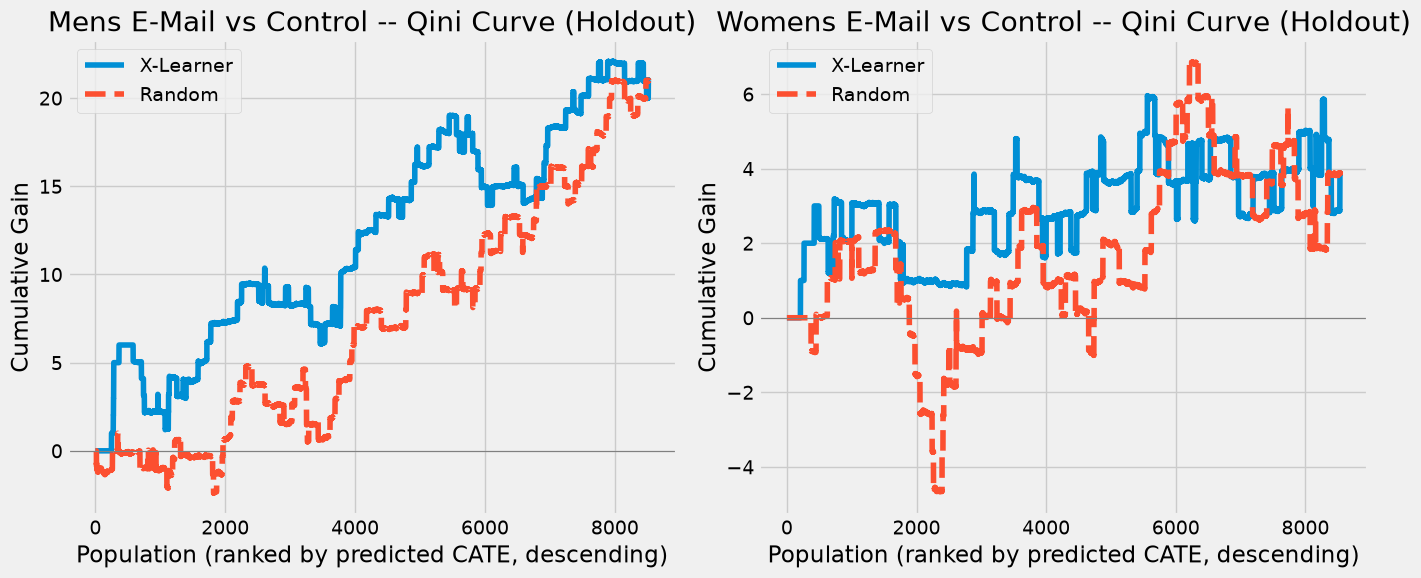

Saved: reports/figures/qini_curves_holdout.png


In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
for ax, (arm, res) in zip(axes, eval_results.items()):
    curve = res.qini_curve
    ax.plot(curve.index, curve[MODEL_COL], label=MODEL_COL)
    ax.plot(curve.index, curve[RANDOM_COL], label=RANDOM_COL, linestyle="--")
    ax.set_title(f"{arm} vs Control -- Qini Curve (Holdout)")
    ax.set_xlabel("Population (ranked by predicted CATE, descending)")
    ax.set_ylabel("Cumulative Gain")
    ax.legend()
    ax.axhline(0, color="grey", linewidth=0.8)

plt.tight_layout()
plt.savefig("../reports/figures/qini_curves_holdout.png", dpi=150)
plt.show()
print("Saved: reports/figures/qini_curves_holdout.png")

In [18]:
import pandas as pd

holdout_scored.to_parquet("../data/holdout_scored.parquet", index=False)
print("Saved: data/holdout_scored.parquet", holdout_scored.shape)

qini_curve_frames = []
for arm, res in eval_results.items():
    curve = res.qini_curve.reset_index().rename(columns={"index": "population"})
    curve.insert(0, "arm", arm)
    qini_curve_frames.append(curve)
qini_curves_long = pd.concat(qini_curve_frames, ignore_index=True)
qini_curves_long.to_parquet("../reports/qini_curves_holdout.parquet", index=False)
print("Saved: reports/qini_curves_holdout.parquet", qini_curves_long.shape)
print(qini_curves_long.head())
print(qini_curves_long["arm"].value_counts())


Saved: data/holdout_scored.parquet (12800, 14)
Saved: reports/qini_curves_holdout.parquet (17063, 4)
           arm  population  X-Learner  Random
0  Mens E-Mail           0        0.0     0.0
1  Mens E-Mail           1        0.0     0.0
2  Mens E-Mail           2        0.0     0.0
3  Mens E-Mail           3        0.0     0.0
4  Mens E-Mail           4        0.0     0.0
arm
Womens E-Mail    8539
Mens E-Mail      8524
Name: count, dtype: int64


In [ ]:
import numpy as np

print("Kernel exec count right now (before this check):", get_ipython().execution_count)

print("train_scored exists:", 'train_scored' in dir())
print("train_scored shape:", train_scored.shape)
print("t_groups (current, post exec=25 fit):", t_groups)

cols = [f"cate_{arm.replace(' ', '_').replace('-', '')}" for arm in t_groups]
print("expected cate columns in train_scored:", cols)
print("columns present:", [c in train_scored.columns for c in cols])

for i, (arm, col) in enumerate(zip(t_groups, cols)):
    frozen = train_scored[col].to_numpy()
    current = cate[:, i]
    same_shape = frozen.shape == current.shape
    exact_equal = np.array_equal(frozen, current) if same_shape else False
    max_abs_diff = np.max(np.abs(frozen - current)) if same_shape else None
    n_diff = int(np.sum(frozen != current)) if same_shape else None
    print(f"\n--- {arm} ---")
    print("frozen (pre-session, in train_scored) shape:", frozen.shape, " current (exec=25 cate) shape:", current.shape)
    print("bit-exact identical:", exact_equal)
    print("max abs diff:", max_abs_diff)
    print("n differing elements:", n_diff, "/", len(current))
    print("frozen[:3]: ", frozen[:3])
    print("current[:3]:", current[:3])


Kernel exec count right now (before this check): 61
train_scored exists: True
train_scored shape: (51200, 14)
t_groups (current, post exec=25 fit): ['Mens E-Mail', 'Womens E-Mail']
expected cate columns in train_scored: ['cate_Mens_EMail', 'cate_Womens_EMail']
columns present: [True, True]

--- Mens E-Mail ---
frozen (pre-session, in train_scored) shape: (51200,)  current (exec=25 cate) shape: (51200,)
bit-exact identical: True
max abs diff: 0.0
n differing elements: 0 / 51200
frozen[:3]:  [0.00425998 0.00509672 0.00747903]
current[:3]: [0.00425998 0.00509672 0.00747903]

--- Womens E-Mail ---
frozen (pre-session, in train_scored) shape: (51200,)  current (exec=25 cate) shape: (51200,)
bit-exact identical: True
max abs diff: 0.0
n differing elements: 0 / 51200
frozen[:3]:  [0.00279812 0.00035309 0.02079963]
current[:3]: [0.00279812 0.00035309 0.02079963]


In [ ]:
import numpy as np

print("Kernel exec count right now (before this check):", get_ipython().execution_count)
print("p_holdout exists:", 'p_holdout' in dir())
print("X_holdout exists:", 'X_holdout' in dir())
print("holdout_scored exists:", 'holdout_scored' in dir())


cate_holdout_check = xlearner.predict(X=X_holdout.to_numpy(), p=p_holdout, verbose=False)

cols = [f"cate_{arm.replace(' ', '_').replace('-', '')}" for arm in t_groups]
print("expected cate columns in holdout_scored:", cols)
print("columns present:", [c in holdout_scored.columns for c in cols])

for i, (arm, col) in enumerate(zip(t_groups, cols)):
    frozen = holdout_scored[col].to_numpy()
    current = cate_holdout_check[:, i]
    same_shape = frozen.shape == current.shape
    exact_equal = np.array_equal(frozen, current) if same_shape else False
    max_abs_diff = np.max(np.abs(frozen - current)) if same_shape else None
    n_diff = int(np.sum(frozen != current)) if same_shape else None
    print(f"\n--- {arm} ---")
    print("frozen (exec=13-era, in holdout_scored) shape:", frozen.shape, " fresh predict shape:", current.shape)
    print("bit-exact identical:", exact_equal)
    print("max abs diff:", max_abs_diff)
    print("n differing elements:", n_diff, "/", len(current))
    print("frozen[:3]: ", frozen[:3])
    print("fresh[:3]:  ", current[:3])


Kernel exec count right now (before this check): 62
p_holdout exists: True
X_holdout exists: True
holdout_scored exists: True
expected cate columns in holdout_scored: ['cate_Mens_EMail', 'cate_Womens_EMail']
columns present: [True, True]

--- Mens E-Mail ---
frozen (exec=13-era, in holdout_scored) shape: (12800,)  fresh predict shape: (12800,)
bit-exact identical: True
max abs diff: 0.0
n differing elements: 0 / 12800
frozen[:3]:  [0.0081708  0.00344981 0.00864896]
fresh[:3]:   [0.0081708  0.00344981 0.00864896]

--- Womens E-Mail ---
frozen (exec=13-era, in holdout_scored) shape: (12800,)  fresh predict shape: (12800,)
bit-exact identical: True
max abs diff: 0.0
n differing elements: 0 / 12800
frozen[:3]:  [0.00703439 0.00608252 0.00579231]
fresh[:3]:   [0.00703439 0.00608252 0.00579231]


In [ ]:
print("model_mu_c type:", type(xlearner.model_mu_c))
print("models_mu_t keys:", list(xlearner.models_mu_t.keys()))
print("models_mu_t['Mens E-Mail'] type:", type(xlearner.models_mu_t['Mens E-Mail']))
print("models_mu_t['Womens E-Mail'] type:", type(xlearner.models_mu_t['Womens E-Mail']))
print("t_groups:", list(xlearner.t_groups))

import numpy as np
mu0_probe = xlearner.model_mu_c.predict(X_holdout.to_numpy()[:5])
mu1_mens_probe = xlearner.models_mu_t['Mens E-Mail'].predict(X_holdout.to_numpy()[:5])
print("mu0 probe:", mu0_probe)
print("mu1 mens probe:", mu1_mens_probe)


In [62]:
print("ping:", get_ipython().execution_count)

ping: 63


In [63]:
from quadrant_segmentation import assign_quadrants_all_arms, quadrant_count_table, mu_summary

quadrant_results = assign_quadrants_all_arms(xlearner, X_holdout, arms=t_groups)

print("=== mu0_hat / mu1_hat summary (threshold diagnostics) ===")
print(mu_summary(quadrant_results).to_string(index=False))
print()

table = quadrant_count_table(quadrant_results)
print("=== Quadrant counts per arm (holdout, threshold=0.5) ===")
print(table)
print()
print("column totals (should equal len(X_holdout) per arm):", table.sum().to_dict())
print("len(X_holdout):", len(X_holdout))

print()
print("=== Quadrant counts as % of holdout, per arm ===")
print((table / len(X_holdout) * 100).round(3))


=== mu0_hat / mu1_hat summary (threshold diagnostics) ===
          arm  threshold  mu0_hat_mean  mu0_hat_max  mu1_hat_mean  mu1_hat_max  pct_above_threshold_control  pct_above_threshold_treatment
  Mens E-Mail        0.5      0.003979     0.827566      0.012521     0.477278                        0.125                       0.000000
Womens E-Mail        0.5      0.003979     0.827566      0.008948     0.532723                        0.125                       0.007812

=== Quadrant counts per arm (holdout, threshold=0.5) ===
              Mens E-Mail  Womens E-Mail
Persuadable             0              1
Sure Thing              0              0
Lost Cause          12784          12783
Sleeping Dog           16             16

column totals (should equal len(X_holdout) per arm): {'Mens E-Mail': 12800, 'Womens E-Mail': 12800}
len(X_holdout): 12800

=== Quadrant counts as % of holdout, per arm ===
              Mens E-Mail  Womens E-Mail
Persuadable         0.000          0.008
Sure Th

In [ ]:
import importlib
import quadrant_segmentation
importlib.reload(quadrant_segmentation)
from quadrant_segmentation import assign_quadrants_all_arms, quadrant_count_table, mu_summary, base_rate_thresholds

for arm in t_groups:
    tc, tt = base_rate_thresholds(holdout_df, arm)
    print(f"{arm}: threshold_control={tc:.5f}  threshold_treatment={tt:.5f}")
print()

quadrant_results = assign_quadrants_all_arms(xlearner, X_holdout, holdout_df, arms=t_groups)

print("=== mu0_hat / mu1_hat vs. base-rate thresholds ===")
print(mu_summary(quadrant_results).to_string(index=False))
print()

table = quadrant_count_table(quadrant_results)
print("=== Quadrant counts per arm (holdout, base-rate threshold) ===")
print(table)
print()
print("column totals:", table.sum().to_dict(), " len(X_holdout):", len(X_holdout))
print()
print("=== Quadrant counts as % of holdout, per arm ===")
print((table / len(X_holdout) * 100).round(3))


In [64]:
print("ping:", get_ipython().execution_count)

ping: 65


In [65]:
import importlib
import quadrant_segmentation
importlib.reload(quadrant_segmentation)
from quadrant_segmentation import assign_quadrants_all_arms, quadrant_count_table, mu_summary, base_rate_thresholds

for arm in t_groups:
    tc, tt = base_rate_thresholds(holdout_df, arm)
    print(f"{arm}: threshold_control={tc:.5f}  threshold_treatment={tt:.5f}")
print()

quadrant_results = assign_quadrants_all_arms(xlearner, X_holdout, holdout_df, arms=t_groups)

print("=== mu0_hat / mu1_hat vs. base-rate thresholds ===")
print(mu_summary(quadrant_results).to_string(index=False))
print()

table = quadrant_count_table(quadrant_results)
print("=== Quadrant counts per arm (holdout, base-rate threshold) ===")
print(table)
print()
print("column totals:", table.sum().to_dict(), " len(X_holdout):", len(X_holdout))
print()
print("=== Quadrant counts as % of holdout, per arm ===")
print((table / len(X_holdout) * 100).round(3))


Mens E-Mail: threshold_control=0.00798  threshold_treatment=0.01290
Womens E-Mail: threshold_control=0.00798  threshold_treatment=0.00888

=== mu0_hat / mu1_hat vs. base-rate thresholds ===
          arm  threshold_control  threshold_treatment  mu0_hat_mean  mu0_hat_max  mu1_hat_mean  mu1_hat_max  pct_above_threshold_control  pct_above_threshold_treatment
  Mens E-Mail           0.007979             0.012905      0.003979     0.827566      0.012521     0.477278                     7.898438                      36.648438
Womens E-Mail           0.007979             0.008885      0.003979     0.827566      0.008948     0.532723                     7.898438                      42.195312

=== Quadrant counts per arm (holdout, base-rate threshold) ===
              Mens E-Mail  Womens E-Mail
Persuadable          4445           4756
Sure Thing            246            645
Lost Cause           7344           7033
Sleeping Dog          765            366

column totals: {'Mens E-Mail': 12800

In [ ]:
print("ping:", get_ipython().execution_count)

In [66]:
print("ping:", get_ipython().execution_count)

ping: 67


In [67]:
from quadrant_segmentation import assign_quadrants, quadrant_count_table, QUADRANT_ORDER
import pandas as pd

# Original (per-arm) thresholds, for reference
tc_mens, tt_mens = base_rate_thresholds(holdout_df, "Mens E-Mail")
tc_womens, tt_womens = base_rate_thresholds(holdout_df, "Womens E-Mail")
print(f"Original per-arm: Mens tc={tc_mens:.5f} tt={tt_mens:.5f} | Womens tc={tc_womens:.5f} tt={tt_womens:.5f}")

# Pooled treatment threshold: observed conversion rate across BOTH treated arms combined
pooled_mask = holdout_df[TREATMENT_COL].isin(["Mens E-Mail", "Womens E-Mail"])
tt_pooled = float(holdout_df.loc[pooled_mask, "conversion"].mean())
print(f"Pooled treatment threshold (Mens+Womens combined): {tt_pooled:.5f}")
print()

# Re-run BOTH arms with the SAME shared treatment threshold (tt_pooled), control threshold unchanged
results_shared_tt = {
    "Mens E-Mail": assign_quadrants(xlearner, X_holdout, "Mens E-Mail", tc_mens, tt_pooled),
    "Womens E-Mail": assign_quadrants(xlearner, X_holdout, "Womens E-Mail", tc_womens, tt_pooled),
}
table_shared = quadrant_count_table(results_shared_tt)
pct_shared = (table_shared / len(X_holdout) * 100).round(3)

print("=== Quadrant %, SAME pooled threshold_treatment for both arms ===")
print(pct_shared)
print()

# side-by-side comparison against the original per-arm-threshold percentages
orig_pct = pd.DataFrame({
    "Mens E-Mail": [4445, 246, 7344, 765],
    "Womens E-Mail": [4756, 645, 7033, 366],
}, index=list(QUADRANT_ORDER)) / len(X_holdout) * 100

print("=== Comparison: original per-arm threshold_treatment vs. shared pooled threshold_treatment ===")
comparison = pd.DataFrame({
    "Mens_orig": orig_pct["Mens E-Mail"].round(3),
    "Mens_shared_tt": pct_shared["Mens E-Mail"],
    "Womens_orig": orig_pct["Womens E-Mail"].round(3),
    "Womens_shared_tt": pct_shared["Womens E-Mail"],
})
print(comparison)


Original per-arm: Mens tc=0.00798 tt=0.01290 | Womens tc=0.00798 tt=0.00888
Pooled treatment threshold (Mens+Womens combined): 0.01089

=== Quadrant %, SAME pooled threshold_treatment for both arms ===
              Mens E-Mail  Womens E-Mail
Persuadable        46.727         20.375
Sure Thing          2.688          3.297
Lost Cause         45.375         71.727
Sleeping Dog        5.211          4.602

=== Comparison: original per-arm threshold_treatment vs. shared pooled threshold_treatment ===
              Mens_orig  Mens_shared_tt  Womens_orig  Womens_shared_tt
Persuadable      34.727          46.727       37.156            20.375
Sure Thing        1.922           2.688        5.039             3.297
Lost Cause       57.375          45.375       54.945            71.727
Sleeping Dog      5.977           5.211        2.859             4.602
